# Olist Delivery Analysis

## Headline

### Olist Delivers Orders 11 Days Ahead of Estimated Dates — Yet Late Deliveries Run 3.11% Above Industry Benchmark

---

## Business Context

Olist is a Brazilian e-commerce technology ecosystem that empowers small and medium-sized businesses (SMBs) by integrating marketplace sales, logistics, and financial services into a single platform.

Late deliveries damage seller reputation, reduce customer trust, and negatively impact marketplace retention and revenue growth.

---

## Approach

The analysis began by establishing a baseline — calculating the percentage of delivered orders that arrived after their estimated delivery date.

Three operational hypotheses were tested across seven joined datasets using SQL and Python. Order, seller, customer, product, and geolocation datasets were combined to analyze delivery delays, dispatch efficiency, category-level delivery behavior, and delivery distance impact.

The Haversine formula was applied to estimate geographical distance between sellers and customers.

---

## Findings

### Finding 1
7,826 out of 96,478 delivered orders arrived late, resulting in an 8.11% late delivery rate — 3.11% above industry benchmark levels.

### Finding 2
Late delivery orders traveled an average distance of 735 km, which is 150 km more than on-time delivery orders.

### Finding 3
Electronics products were delivered 11.01 days before estimated delivery dates, while other categories were delivered 11.94 days before estimated dates.

### Finding 4
Sellers with more than 36 orders dispatched products within 2.7 days, while sellers with fewer than 36 orders dispatched within 2.9 days.

---

## Recommendations

### Recommendation 1 — Reduce Estimated Delivery Padding

Olist should reduce the 11-day buffer built into estimated delivery dates. The current padding hides operational inefficiencies and delays visibility into real delivery performance.

---

### Recommendation 2 — Prioritize Long-Distance Orders

Orders exceeding 735 km should be prioritized for dispatch within 24 hours of confirmation since long-distance deliveries represent the highest late-delivery risk segment.

---

### Recommendation 3 — Improve Low-Volume Seller Dispatch Efficiency

Low-volume sellers dispatch slower than high-volume sellers. Olist should provide fulfillment guidelines and operational training to sellers with fewer than 36 orders.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import warnings

warnings.filterwarnings('ignore')

customers = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv')

sellers = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_sellers_dataset.csv')

reviews = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv')

items = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv')

products = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv')

geolocation = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_geolocation_dataset.csv')

translation = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/product_category_name_translation.csv')

orders = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv')

payments = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv')

print("Customers Shape :", customers.shape)
print("Geolocation Shape :", geolocation.shape)
print("Order Items Shape :", items.shape)
print("Orders Shape :", orders.shape)
print("Products Shape :", products.shape)
print("Sellers Shape :", sellers.shape)

Customers Shape : (99441, 5)
Geolocation Shape : (1000163, 5)
Order Items Shape : (112650, 7)
Orders Shape : (99441, 8)
Products Shape : (32951, 9)
Sellers Shape : (3095, 4)


# Query 1 — Baseline Late Delivery Rate

 

# Late Delivery Baseline Analysis

This section calculates the percentage of delivered orders that arrived after the estimated delivery date. The result establishes the baseline late delivery rate for the business.

In [2]:
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()

late_delivery = (
    delivered_orders['order_delivered_customer_date'] >
    delivered_orders['order_estimated_delivery_date']
).sum()

total_delivery = delivered_orders['order_id'].count()

late_delivery_rate = (late_delivery / total_delivery) * 100

print("Late Delivery :", late_delivery)
print("Total Delivery :", total_delivery)
print("Late Delivery Rate :", round(late_delivery_rate, 2), "%")

Late Delivery : 7826
Total Delivery : 96478
Late Delivery Rate : 8.11 %


 # Query 2 — Average Distance:
 # Late vs On-Time Orders

# Distance Impact Analysis

This section measures the geographical distance traveled by late and on-time orders using the Haversine formula. The objective is to test whether longer delivery distance contributes to higher late-delivery risk.

In [3]:
# Average geolocation per zip code

geo = geolocation.groupby(
    'geolocation_zip_code_prefix'
).agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

geo.columns = [
    'zip_code_prefix',
    'avg_lat',
    'avg_lng'
]

# Customer geolocation

customer_geo = customers.merge(
    geo,
    left_on='customer_zip_code_prefix',
    right_on='zip_code_prefix',
    how='left'
)

# Seller geolocation

seller_geo = sellers.merge(
    geo,
    left_on='seller_zip_code_prefix',
    right_on='zip_code_prefix',
    how='left'
)

# Merge datasets

distance_df = items.merge(
    orders,
    on='order_id',
    how='inner'
)

distance_df = distance_df.merge(
    customer_geo[['customer_id', 'avg_lat', 'avg_lng']],
    on='customer_id',
    how='left'
)

distance_df = distance_df.merge(
    seller_geo[['seller_id', 'avg_lat', 'avg_lng']],
    on='seller_id',
    how='left',
    suffixes=('_customer', '_seller')
)

# Keep delivered orders only

distance_df = distance_df[
    distance_df['order_status'] == 'delivered'
].copy()

# Convert date columns

distance_df['order_delivered_customer_date'] = pd.to_datetime(
    distance_df['order_delivered_customer_date']
)

distance_df['order_estimated_delivery_date'] = pd.to_datetime(
    distance_df['order_estimated_delivery_date']
)

# Haversine Formula

from math import radians, sin, cos, acos

def haversine(lat1, lon1, lat2, lon2):

    if (
        pd.isnull(lat1) or pd.isnull(lon1) or
        pd.isnull(lat2) or pd.isnull(lon2)
    ):
        return np.nan

    value = (
        cos(radians(lat1)) *
        cos(radians(lat2)) *
        cos(radians(lon1) - radians(lon2)) +
        sin(radians(lat1)) *
        sin(radians(lat2))
    )

    # Prevent math domain error

    value = min(1, max(-1, value))

    return 6371 * acos(value)

# Calculate distance

distance_df['distance_km'] = distance_df.apply(
    lambda x: haversine(
        x['avg_lat_seller'],
        x['avg_lng_seller'],
        x['avg_lat_customer'],
        x['avg_lng_customer']
    ),
    axis=1
)

# Create delivery flag

distance_df['delivery_flag'] = np.where(
    distance_df['order_delivered_customer_date'] >
    distance_df['order_estimated_delivery_date'],
    'Late',
    'On_Time'
)

# Average distance by delivery type

avg_distance = distance_df.groupby(
    'delivery_flag'
)['distance_km'].mean().reset_index()

avg_distance['distance_km'] = avg_distance['distance_km'].round(2)

print(avg_distance)

  delivery_flag  distance_km
0          Late       735.05
1       On_Time       584.33


# Query 3 — Average Delivery Days:
# Electronics vs Other Categories

# Category-Level Delivery Analysis

This section compares delivery timing between electronics products and all other product categories to evaluate whether category type influences delivery performance.

In [4]:
# Merge product translation

products_cat = products.merge(
    translation,
    on='product_category_name',
    how='left'
)

# Merge datasets

category_df = items.merge(
    orders,
    on='order_id',
    how='inner'
)

category_df = category_df.merge(
    products_cat,
    on='product_id',
    how='left'
)

# Keep delivered orders only

category_df = category_df[
    category_df['order_status'] == 'delivered'
].copy()

# Convert datetime columns

category_df['order_delivered_customer_date'] = pd.to_datetime(
    category_df['order_delivered_customer_date']
)

category_df['order_estimated_delivery_date'] = pd.to_datetime(
    category_df['order_estimated_delivery_date']
)

# IMPORTANT:
# Remove duplicate order-category combinations
# to match SQL DISTINCT logic

category_df = category_df[[
    'order_id',
    'product_category_name_english',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]].drop_duplicates()

# Delivery difference

category_df['delivery_days_diff'] = (
    category_df['order_delivered_customer_date'] -
    category_df['order_estimated_delivery_date']
).dt.days

# Electronics average

electronics_avg = category_df.loc[
    category_df['product_category_name_english'] == 'electronics',
    'delivery_days_diff'
].mean()

# Other categories average

others_avg = category_df.loc[
    category_df['product_category_name_english'] != 'electronics',
    'delivery_days_diff'
].mean()

# Final Output

result = pd.DataFrame({
    'Category_Type': [
        'Electronics',
        'Other Categories'
    ],
    'Average_Days_Before_Estimated_Date': [
        round(abs(electronics_avg), 2),
        round(abs(others_avg), 2)
    ]
})

print(result)

      Category_Type  Average_Days_Before_Estimated_Date
0       Electronics                               11.02
1  Other Categories                               11.94


# Query 4 — Seller Dispatch Time:
# High vs Low Volume Sellers

# Seller Dispatch Analysis

This section compares dispatch speed between high-volume and low-volume sellers to determine whether seller order volume affects operational efficiency.

In [5]:
# Merge datasets

dispatch_df = orders.merge(
    items,
    on='order_id',
    how='inner'
)

# Keep delivered orders only

dispatch_df = dispatch_df[
    dispatch_df['order_status'] == 'delivered'
].copy()

# Convert datetime columns

dispatch_df['order_delivered_carrier_date'] = pd.to_datetime(
    dispatch_df['order_delivered_carrier_date']
)

dispatch_df['order_approved_at'] = pd.to_datetime(
    dispatch_df['order_approved_at']
)

# Remove missing dates

dispatch_df = dispatch_df.dropna(
    subset=[
        'order_delivered_carrier_date',
        'order_approved_at'
    ]
)

# Seller order count

seller_orders = dispatch_df.groupby(
    'seller_id'
)['order_id'].count().reset_index()

seller_orders.columns = [
    'seller_id',
    'order_by_seller'
]

# Merge seller order counts

dispatch_df = dispatch_df.merge(
    seller_orders,
    on='seller_id',
    how='left'
)

# Match SQL DATEDIFF behavior exactly
# Ignore time component

dispatch_df['dispatch_days'] = (
    dispatch_df['order_delivered_carrier_date'].dt.normalize() -
    dispatch_df['order_approved_at'].dt.normalize()
).dt.days

# High-volume sellers (>36 orders)

high_volume_avg = dispatch_df.loc[
    dispatch_df['order_by_seller'] > 36,
    'dispatch_days'
].mean()

# Low-volume sellers (<=36 orders)

low_volume_avg = dispatch_df.loc[
    dispatch_df['order_by_seller'] <= 36,
    'dispatch_days'
].mean()

# Final Output

result = pd.DataFrame({
    'Seller_Type': [
        'High Volume Sellers (>36 Orders)',
        'Low Volume Sellers (<=36 Orders)'
    ],
    'Average_Dispatch_Days': [
        round(high_volume_avg, 1),
        round(low_volume_avg, 1)
    ]
})

print(result)

                        Seller_Type  Average_Dispatch_Days
0  High Volume Sellers (>36 Orders)                    2.7
1  Low Volume Sellers (<=36 Orders)                    2.9


# Visualization


# Visualization 1 — Late Delivery Rate

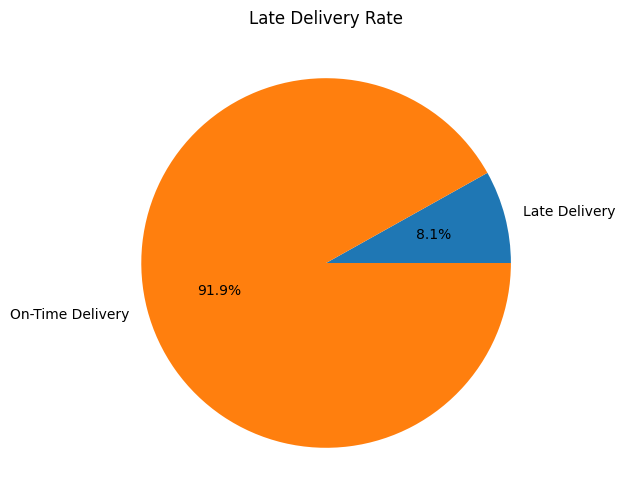

In [6]:
late_count = late_delivery
on_time_count = total_delivery - late_delivery

labels = ['Late Delivery', 'On-Time Delivery']
values = [late_count, on_time_count]

plt.figure(figsize=(6,6))

plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title('Late Delivery Rate')

plt.savefig('Late_Delivery_Rate.png', bbox_inches='tight')

plt.show()

# Visualization 2 —
# Distance: Late vs On-Time Orders

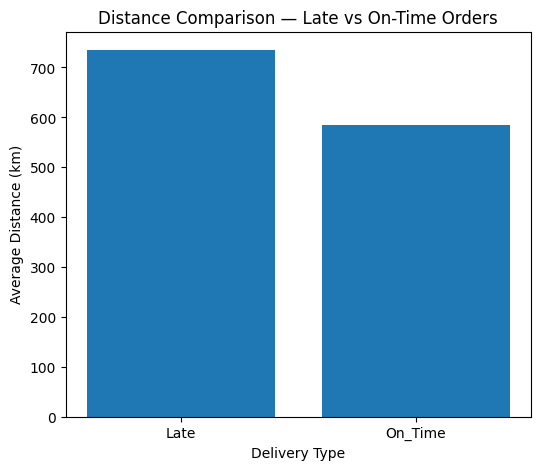

In [7]:
distance_plot = avg_distance.copy()

plt.figure(figsize=(6,5))

plt.bar(
    distance_plot['delivery_flag'],
    distance_plot['distance_km']
)

plt.title('Distance Comparison — Late vs On-Time Orders')
plt.xlabel('Delivery Type')
plt.ylabel('Average Distance (km)')

plt.show()

# Visualization 3 —
# Electronics vs Other Categories

      Category_Type  Average_Days_Before_Estimated_Date
0       Electronics                               11.02
1  Other Categories                               11.94


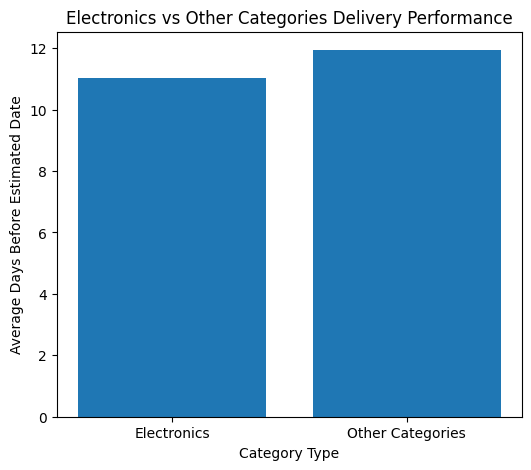

In [8]:
category_result = pd.DataFrame({
    'Category_Type': [
        'Electronics',
        'Other Categories'
    ],
    'Average_Days_Before_Estimated_Date': [
        round(abs(electronics_avg), 2),
        round(abs(others_avg), 2)
    ]
})

print(category_result)

plt.figure(figsize=(6,5))

plt.bar(
    category_result['Category_Type'],
    category_result['Average_Days_Before_Estimated_Date']
)

plt.title('Electronics vs Other Categories Delivery Performance')
plt.xlabel('Category Type')
plt.ylabel('Average Days Before Estimated Date')

plt.show()

# Visualization 4 —
# Seller Dispatch Time Comparison

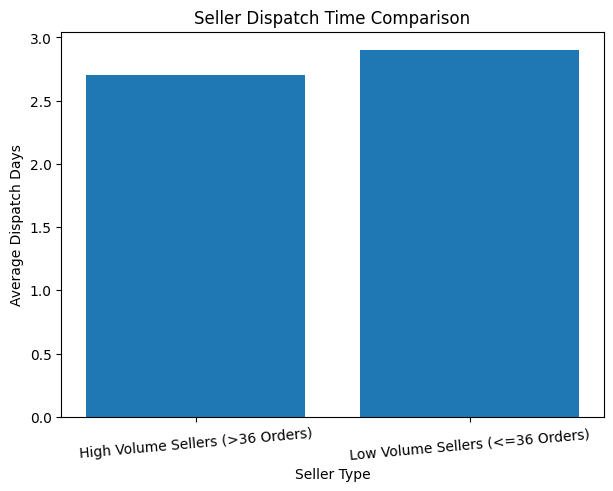

In [9]:
plt.figure(figsize=(7,5))

plt.bar(
    result['Seller_Type'],
    result['Average_Dispatch_Days']
)

plt.title('Seller Dispatch Time Comparison')
plt.xlabel('Seller Type')
plt.ylabel('Average Dispatch Days')

plt.xticks(rotation=5)

plt.show()

# Executive Summary

Olist's late delivery rate of 8.11% sits 3.11% above the industry benchmark of 5%. Analysis across 96,478 delivered orders shows that late deliveries travel an average of 735 km compared to 584 km for on-time orders, suggesting distance is a primary driver. However, estimated delivery dates are padded by 11+ days, partially masking operational performance. High volume sellers dispatch in 2.7 days versus 2.9 days for low volume sellers, indicating dispatch speed can be improved across the seller base. Reducing average dispatch time and flagging long-distance orders for priority handling are the two levers most likely to close the gap.
